# CIM 2025-2026 — M.EEC0045
## Lab Assignment 3 — Parte 2: Hybrid Video Decoder
### Experiments with Hybrid Video Decoding - Video Reconstruction and Performance Evaluation

Este notebook implementa a **Parte 2** do Assignment 3, cobrindo:
- **2.1.i** — Inverse quantisation usando matriz base e quality factor
- **2.1.ii** — Inverse DCT2 transform para blocos 8×8
- **2.1.iii** — Recuperação de pixel data de imagens motion-compensated
- **2.1.iv** — Avaliação de qualidade (PSNR e SSIM)
- **2.2** — Experimentos variando quantiser scale factor, MB size, e GOP structure

---
## 0. Importações e Dependências

In [20]:
import cv2
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.fftpack import dct, idct
from skimage.metrics import structural_similarity as ssim
from pathlib import Path
import pandas as pd

print("Todas as dependências importadas com sucesso.")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")

Todas as dependências importadas com sucesso.
OpenCV version: 4.13.0
NumPy version: 2.4.4


---
## 1. Importação das Matrizes MPEG e Funções de Part1

As funções de quantização, DCT e qualidade de Part1 são reutilizadas aqui com pequenas adaptações.

In [21]:
# =============================================================
# MATRIZES MPEG PADRÃO (do annex da professora)
# =============================================================

Q_INTRA = np.array([
    [8, 16, 19, 22, 26, 27, 29, 34],
    [16, 16, 22, 24, 27, 29, 34, 37],
    [19, 22, 26, 27, 29, 34, 34, 38],
    [22, 22, 26, 27, 29, 34, 37, 40],
    [22, 26, 27, 29, 32, 35, 40, 48],
    [26, 27, 29, 32, 35, 40, 48, 58],
    [26, 27, 29, 34, 38, 46, 56, 69],
    [27, 29, 35, 38, 46, 56, 69, 83]
], dtype=np.float64)

Q_INTER = np.array([
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16]
], dtype=np.float64)

print("Matrizes de quantização MPEG definidas.")

Matrizes de quantização MPEG definidas.


---
## 2.1.i — Inverse Quantisation

In [22]:
def dequantize_block(block, mode='I', scale=1):
    """
    2.1.i — Inverse quantisation de um bloco 8x8.
    
    Aplica a inversa da quantização MPEG usando a matriz base (Q_INTRA ou Q_INTER)
    e o quality factor (scale).
    
    Parâmetros
    ----------
    block : array 8x8 de coeficientes quantizados (int)
    mode  : 'I' (intra), 'P' (predictive), ou 'B' (bidirectional)
            I-frames usam Q_INTRA; P e B frames usam Q_INTER
    scale : quality factor (quantiser scale factor)
            valores maiores → mais quantização → menor qualidade
    
    Retorna
    -------
    Array float64 com coeficientes DCT dequantizados (reconstruídos).
    """
    Q = Q_INTRA if mode == 'I' else Q_INTER
    return (block * (Q * scale)).astype(np.float64)


def dequantize_frame(q_frame, mode='I', scale=1, block_size=8):
    """
    Aplica inverse quantisation a todos os blocos 8x8 de um frame quantizado.
    
    Parâmetros
    ----------
    q_frame    : frame quantizado (altura e largura múltiplos de block_size)
    mode       : tipo de frame ('I', 'P', ou 'B')
    scale      : quality factor
    block_size : tamanho do bloco (padrão 8)
    
    Retorna
    -------
    Array float64 com coeficientes DCT reconstruídos.
    """
    H, W = q_frame.shape
    dq_frame = np.zeros_like(q_frame, dtype=np.float64)
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            blk = q_frame[i:i+block_size, j:j+block_size]
            if blk.shape == (block_size, block_size):
                dq_frame[i:i+block_size, j:j+block_size] = dequantize_block(blk, mode, scale)
    return dq_frame


print("2.1.i — Funções de inverse quantisation definidas.")

2.1.i — Funções de inverse quantisation definidas.


---
## 2.1.ii — Inverse DCT2 Transform

In [23]:
def apply_idct(block):
    """
    2.1.ii — Inverse DCT2 (IDCT2) a um bloco 8x8.
    
    Aplica a transformada inversa de cossenos discretos a um bloco 8x8 de
    coeficientes DCT, convertendo-os de volta para o domínio espacial.
    
    Parâmetros
    ----------
    block : array 8x8 de coeficientes DCT (float64)
    
    Retorna
    -------
    Array 8x8 float64 com pixels reconstruídos.
    """
    return idct(idct(block.T, norm='ortho').T, norm='ortho')


def apply_idct_to_frame(dct_frame, block_size=8):
    """
    2.1.ii — Aplica IDCT2 a todos os blocos block_size x block_size de um frame.
    
    A ideia é invocar apply_idct sucessivamente para cada bloco quantizado 8x8.
    
    Parâmetros
    ----------
    dct_frame  : frame com coeficientes DCT (float64)
    block_size : tamanho do bloco (padrão 8)
    
    Retorna
    -------
    Frame reconstruído (float64) no domínio espacial.
    """
    H, W = dct_frame.shape
    rec_frame = np.zeros_like(dct_frame, dtype=np.float64)
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            blk = dct_frame[i:i+block_size, j:j+block_size]
            if blk.shape == (block_size, block_size):
                rec_frame[i:i+block_size, j:j+block_size] = apply_idct(blk)
    return rec_frame


print("2.1.ii — Funções de inverse DCT2 definidas.")

2.1.ii — Funções de inverse DCT2 definidas.


---
## 2.1.iii — Motion-Compensated Image Reconstruction

Função para recuperar a full pixel data de uma imagem motion-compensated dentro
de uma sequência de vídeo comprimida.

In [24]:
def get_predicted_block(ref_frame, row_mb, col_mb, dx, dy, mb_size):
    """
    Extrai um bloco predito de um frame de referência usando motion vectors.
    
    Parâmetros
    ----------
    ref_frame : frame de referência (uint8, 2D)
    row_mb    : linha do macrobloco no frame corrente
    col_mb    : coluna do macrobloco no frame corrente
    dx        : deslocamento horizontal do motion vector
    dy        : deslocamento vertical do motion vector
    mb_size   : tamanho do macrobloco
    
    Retorna
    -------
    Bloco predito (float64) extraído da referência com aplicação de MV.
    """
    H, W = ref_frame.shape
    
    # Posição no frame de referência
    y_ref = row_mb * mb_size + dy
    x_ref = col_mb * mb_size + dx
    
    # Clip aos limites do frame
    y_start = max(0, min(y_ref, H - mb_size))
    x_start = max(0, min(x_ref, W - mb_size))
    y_end = min(y_start + mb_size, H)
    x_end = min(x_start + mb_size, W)
    
    predicted = ref_frame[y_start:y_end, x_start:x_end].astype(np.float64)
    
    # Pad se necessário
    if predicted.shape != (mb_size, mb_size):
        padded = np.zeros((mb_size, mb_size), dtype=np.float64)
        padded[:predicted.shape[0], :predicted.shape[1]] = predicted
        predicted = padded
    
    return predicted


def reconstruct_frame_from_compressed(compressed_data, ref_frames, original_shape, block_size=8):
    """
    2.1.iii — Recupera a full pixel data de uma imagem motion-compensated.
    
    Este é o decoder principal que:
    1. Dequantiza os coeficientes DCT
    2. Aplica IDCT2 para recuperar o residual
    3. Usa motion vectors para resgatar a predição do frame de referência
    4. Adiciona o residual à predição para obter a reconstrução final
    
    Parâmetros
    ----------
    compressed_data : dicionário com chaves:
        - 'type': 'I', 'P', ou 'B'
        - 'q_frame': array quantizado (coeficientes DCT)
        - 'mv_list': lista de motion vectors (tuplos)
        - 'ref_idx' ou 'fwd_idx'/'bwd_idx': índices dos frames de referência
        - 'scale': quantiser scale factor
        - 'block_size': tamanho do macrobloco usado na codificação
    
    ref_frames : lista de frames de referência decodificados (uint8)
               ou valor único para I-frames
    
    original_shape : tuplo (H, W) da dimensão original do frame
    block_size : tamanho do bloco (padrão 8 para DCT)
    
    Retorna
    -------
    Frame reconstruído (uint8, clipped a [0, 255]).
    """
    frame_type = compressed_data.get('type', 'I')
    q_frame = compressed_data['q_frame']
    mv_list = compressed_data.get('mv_list', [])
    scale = compressed_data.get('scale', 1)
    mb_size = compressed_data.get('block_size', 16)
    
    H, W = original_shape
    reconstructed = np.zeros((H, W), dtype=np.float64)
    
    # ---- I-FRAME: sem predição, residual = pixel data ----
    if frame_type == 'I':
        # Dequantiza
        dq_frame = dequantize_frame(q_frame, mode='I', scale=scale)
        # Inverse DCT
        reconstructed = apply_idct_to_frame(dq_frame)
    
    # ---- P-FRAME e B-FRAME: com predição ----
    else:
        # Dequantiza o residual
        dq_residual = dequantize_frame(q_frame, mode=frame_type, scale=scale)
        # Inverse DCT do residual
        residual = apply_idct_to_frame(dq_residual)
        
        # Inicializa frame reconstruído com zeros
        reconstructed = np.zeros((H, W), dtype=np.float64)
        
        # Processa cada motion vector
        if frame_type == 'P':
            # P-frame: forward prediction apenas
            ref = ref_frames if isinstance(ref_frames, np.ndarray) else ref_frames[0]
            
            for mv in mv_list:
                row_mb, col_mb, dx, dy, mb_used = mv[:5]
                
                # Predito = extrair do frame de referência com motion vector
                predicted = get_predicted_block(ref, row_mb, col_mb, dx, dy, mb_used)
                
                # Residual = extrair do decoded residual frame
                residual_block = residual[row_mb*mb_used:(row_mb+1)*mb_used, 
                                         col_mb*mb_used:(col_mb+1)*mb_used]
                
                # Reconstrói = predição + residual
                reconstructed[row_mb*mb_used:(row_mb+1)*mb_used,
                             col_mb*mb_used:(col_mb+1)*mb_used] = predicted + residual_block
        
        elif frame_type == 'B':
            # B-frame: forward e backward prediction (interpolação)
            ref_fwd = ref_frames if isinstance(ref_frames, np.ndarray) else ref_frames[0]
            ref_bwd = ref_frames[1] if isinstance(ref_frames, list) and len(ref_frames) > 1 else ref_fwd
            
            for mv in mv_list:
                row_mb, col_mb, dx_fwd, dy_fwd, dx_bwd, dy_bwd, mb_used = mv
                
                # Predito forward
                predicted_fwd = get_predicted_block(ref_fwd, row_mb, col_mb, dx_fwd, dy_fwd, mb_used)
                # Predito backward
                predicted_bwd = get_predicted_block(ref_bwd, row_mb, col_mb, dx_bwd, dy_bwd, mb_used)
                # Interpolação (média)
                predicted = (predicted_fwd + predicted_bwd) / 2.0
                
                # Residual
                residual_block = residual[row_mb*mb_used:(row_mb+1)*mb_used,
                                         col_mb*mb_used:(col_mb+1)*mb_used]
                
                # Reconstrói
                reconstructed[row_mb*mb_used:(row_mb+1)*mb_used,
                             col_mb*mb_used:(col_mb+1)*mb_used] = predicted + residual_block
    
    # Clip a [0, 255] e converte para uint8
    reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)
    return reconstructed


print("2.1.iii — Função de motion-compensated reconstruction definida.")

2.1.iii — Função de motion-compensated reconstruction definida.


---
## 2.1.iv — Quality Evaluation (PSNR and SSIM)

In [25]:
def psnr(original, compressed):
    """
    2.1.iv — Calcula PSNR (Peak Signal-to-Noise Ratio) entre dois frames.
    
    Parâmetros
    ----------
    original   : frame original (uint8 ou float)
    compressed : frame reconstruído (uint8 ou float)
    
    Retorna
    -------
    PSNR em dB (float). Valores maiores indicam melhor qualidade.
    """
    mse_val = np.mean((original.astype(np.float64) - compressed.astype(np.float64)) ** 2)
    if mse_val == 0:
        return float('inf')
    max_pixel = 255.0
    return 20 * np.log10(max_pixel / np.sqrt(mse_val))


def compute_ssim(original, compressed):
    """
    2.1.iv — Calcula SSIM (Structural Similarity Index) entre dois frames.
    
    Parâmetros
    ----------
    original   : frame original (uint8 ou float)
    compressed : frame reconstruído (uint8 ou float)
    
    Retorna
    -------
    SSIM (float, range [-1, 1]). Valor 1 = idêntico, valores maiores são melhores.
    """
    o = original.astype(np.uint8)
    c = np.clip(compressed, 0, 255).astype(np.uint8)
    return ssim(o, c, data_range=c.max() - c.min())


print("2.1.iv — Funções de qualidade (PSNR e SSIM) definidas.")

2.1.iv — Funções de qualidade (PSNR e SSIM) definidas.


---
## 2.2 — Decoder Principal e Carregamento de Dados Comprimidos

In [32]:
def decode_sequence(compressed_path, frames_y_original=None):
    """
    Decoder principal que carrega dados comprimidos e reconstrói a sequência.
    
    Parâmetros
    ----------
    compressed_path : caminho para arquivo .pkl comprimido (gerado por Part1)
    frames_y_original : sequência original de frames (para comparação de qualidade)
    
    Retorna
    -------
    reconstructed_frames : lista de frames reconstruídos (uint8)
    params : dicionário com parâmetros de codificação
    metrics : dicionário com métricas de qualidade por frame
    """
    
    # Carrega dados comprimidos
    with open(compressed_path, 'rb') as f:
        data = pickle.load(f)
    
    compressed_frames = data['compressed']
    gop_seq = data['gop_seq']
    params = data['params']
    
    n_frames = len(compressed_frames)
    compressed_shape = compressed_frames[0]['q_frame'].shape
    
    # Determina dimensão do frame e valida compatibilidade
    frames_y_for_metrics = frames_y_original
    if frames_y_original is not None and len(frames_y_original) > 0:
        if frames_y_original[0].shape == compressed_shape:
            original_shape = frames_y_original[0].shape
        else:
            frames_y_for_metrics = None
            original_shape = compressed_shape
    else:
        original_shape = compressed_shape
    
    reconstructed_frames = [None] * n_frames
    decoded_buffer = [None] * n_frames  # Buffer com frames já decodificados
    b_frame_indices = []
    
    metrics = {'psnr': [], 'ssim': []}
    
    print(f"\n{'='*70}")
    print(f"DECODER | GOP N={params['N']} M={params['M']} | "
          f"MB={params['block_size']}×{params['block_size']} | "
          f"QS={params['quant_scale']}")
    print(f"Sequência GOP: {gop_seq[:min(20, n_frames)]}...")
    print(f"{'='*70}\n")
    
    # Primeiro passo: decodifica I e P frames
    for idx, compressed_data in enumerate(compressed_frames):
        frame_type = compressed_data['type']
        rec = None
        
        # ---- I-FRAME ----
        if frame_type == 'I':
            rec = reconstruct_frame_from_compressed(
                compressed_data, None, original_shape,
                block_size=8
            )
            reconstructed_frames[idx] = rec
            decoded_buffer[idx] = rec
        
        # ---- P-FRAME ----
        elif frame_type == 'P':
            # Procura frame de referência (último I ou P decodificado)
            ref_idx = compressed_data.get('ref_idx', idx - 1)
            ref = decoded_buffer[ref_idx]
            
            rec = reconstruct_frame_from_compressed(
                compressed_data, ref, original_shape,
                block_size=8
            )
            reconstructed_frames[idx] = rec
            decoded_buffer[idx] = rec
        
        # ---- B-FRAME ----
        elif frame_type == 'B':
            b_frame_indices.append(idx)
        
        # Calcula métricas se original disponível e rec válido
        if rec is not None:
            if frames_y_for_metrics is not None and idx < len(frames_y_for_metrics):
                orig = frames_y_for_metrics[idx]
                psnr_val = psnr(orig, rec)
                ssim_val = compute_ssim(orig, rec)
                metrics['psnr'].append(psnr_val)
                metrics['ssim'].append(ssim_val)
                print(f"  Frame {idx:3d} [{frame_type}] | PSNR: {psnr_val:7.2f} dB | SSIM: {ssim_val:6.4f}")
            else:
                print(f"  Frame {idx:3d} [{frame_type}] | Reconstruído")
    
    # Segundo passo: decodifica B-frames depois de refs disponíveis
    for idx in b_frame_indices:
        compressed_data = compressed_frames[idx]
        frame_type = compressed_data['type']
        fwd_idx = compressed_data.get('fwd_idx', idx - 1)
        bwd_idx = compressed_data.get('bwd_idx', idx + 1)
        
        ref_fwd = decoded_buffer[fwd_idx] if fwd_idx >= 0 else decoded_buffer[0]
        ref_bwd = decoded_buffer[bwd_idx] if bwd_idx < len(decoded_buffer) else decoded_buffer[-1]
        
        if ref_fwd is None or ref_bwd is None:
            print(f"  Frame {idx:3d} [{frame_type}] | [INFO] Referências indisponíveis, skip")
            continue
        
        rec = reconstruct_frame_from_compressed(
            compressed_data, [ref_fwd, ref_bwd], original_shape,
            block_size=8
        )
        reconstructed_frames[idx] = rec
        
        if frames_y_for_metrics is not None and idx < len(frames_y_for_metrics):
            orig = frames_y_for_metrics[idx]
            psnr_val = psnr(orig, rec)
            ssim_val = compute_ssim(orig, rec)
            metrics['psnr'].append(psnr_val)
            metrics['ssim'].append(ssim_val)
            print(f"  Frame {idx:3d} [{frame_type}] | PSNR: {psnr_val:7.2f} dB | SSIM: {ssim_val:6.4f}")
        else:
            print(f"  Frame {idx:3d} [{frame_type}] | Reconstruído")
    
    # Resumo
    print(f"\n{'='*70}")
    if metrics['psnr']:
        print(f"PSNR médio: {np.mean(metrics['psnr']):.2f} dB "
              f"(min: {np.min(metrics['psnr']):.2f}, max: {np.max(metrics['psnr']):.2f})")
        print(f"SSIM médio: {np.mean(metrics['ssim']):.4f} "
              f"(min: {np.min(metrics['ssim']):.4f}, max: {np.max(metrics['ssim']):.4f})")
    print(f"{'='*70}\n")
    
    return reconstructed_frames, params, metrics


print("Decoder principal definido.")

Decoder principal definido.


---
## 2.3 — Carregamento de Sequência Original

In [30]:
# Carrega a sequência original de frames (do output de Part1)
# Ajuste os caminhos conforme necessário

def load_original_frames():
    """
    Carrega frames originais a partir de ficheiros de vídeo ou sequências de imagens.
    """
    frames_y = []

    # Prioriza sequência de imagens (car) para compatibilidade com os ficheiros comprimidos
    image_dir = Path("video sequences/sequence of still images - car")
    if image_dir.exists():
        image_files = sorted(image_dir.glob("*.bmp"))
        for img_path in image_files:
            gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if gray is None:
                continue
            H, W = gray.shape
            H_new = (H // 8) * 8
            W_new = (W // 8) * 8
            gray = gray[:H_new, :W_new]
            frames_y.append(gray)
        if frames_y:
            print(f"Carregados {len(frames_y)} frames de {image_dir}")
            return frames_y

    # Fallback: tenta carregar ficheiros de vídeo em caminhos conhecidos
    video_candidates = [
        Path("input.mp4"),
        Path("video sequences/input.mp4"),
        Path("video sequences/sound_timbre_mp4.mp4"),
    ]

    for video_path in video_candidates:
        if video_path.exists():
            cap = cv2.VideoCapture(str(video_path))
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                # Converte para escala de cinza
                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                # Redimensiona para múltiplo de 8 (para DCT)
                H, W = gray.shape
                H_new = (H // 8) * 8
                W_new = (W // 8) * 8
                gray = gray[:H_new, :W_new]
                frames_y.append(gray)
            cap.release()
            print(f"Carregados {len(frames_y)} frames de {video_path}")
            return frames_y

    print("[INFO] Nenhuma fonte de vídeo/imagens encontrada.")
    return frames_y


frames_y_original = load_original_frames()
if frames_y_original:
    print(f"Dimensão dos frames: {frames_y_original[0].shape}")
    print(f"Total de frames carregados: {len(frames_y_original)}")

Carregados 11 frames de video sequences/sequence of still images - car
Dimensão dos frames: (256, 256)
Total de frames carregados: 11


---
## 2.4 — Experiments com Diferentes Parâmetros

Avalia a qualidade da reconstrução variando:
- **Quantiser scale factor** (QS): 1, 2, 4, 8
- **Macroblock size** (MB): 8, 16
- **GOP structure**: N=9 (GOP length), M=1, 3 (distance between P-frames)

In [33]:
def run_decoding_experiments():
    """
    Executa experimentos de decoding com diferentes configurações
    e avalia a qualidade segundo PSNR e SSIM.
    """
    
    if not frames_y_original:
        print("[ERRO] Nenhum frame original carregado. Execute a célula anterior.")
        return None
    
    results = []
    compressed_dir = 'compressed'
    
    if not os.path.isdir(compressed_dir):
        print(f"[ERRO] Pasta {compressed_dir} não encontrada. Execute Part1 primeiro.")
        return None
    
    # Lista ficheiros comprimidos
    compressed_files = sorted([f for f in os.listdir(compressed_dir) if f.endswith('.pkl')])
    
    if not compressed_files:
        print(f"[ERRO] Nenhum ficheiro comprimido encontrado em {compressed_dir}.")
        return None
    
    print(f"\nEncontrados {len(compressed_files)} ficheiros comprimidos.\n")
    
    for filename in compressed_files:
        filepath = os.path.join(compressed_dir, filename)
        print(f"\nProcessando: {filename}")
        
        try:
            rec_frames, params, metrics = decode_sequence(filepath, frames_y_original)
            
            result = {
                'filename': filename,
                'gop_N': params['N'],
                'gop_M': params['M'],
                'mb_size': params['block_size'],
                'quantiser_scale': params['quant_scale'],
                'psnr_avg': np.mean(metrics['psnr']) if metrics['psnr'] else None,
                'psnr_min': np.min(metrics['psnr']) if metrics['psnr'] else None,
                'psnr_max': np.max(metrics['psnr']) if metrics['psnr'] else None,
                'ssim_avg': np.mean(metrics['ssim']) if metrics['ssim'] else None,
                'ssim_min': np.min(metrics['ssim']) if metrics['ssim'] else None,
                'ssim_max': np.max(metrics['ssim']) if metrics['ssim'] else None,
            }
            results.append(result)
        
        except Exception as e:
            print(f"[ERRO] Falha ao processar {filename}: {str(e)}")
            continue
    
    return results


# Executa experimentos
experiment_results = run_decoding_experiments()


Encontrados 5 ficheiros comprimidos.


Processando: compressed_N12_M3_MB16_QS1.pkl

DECODER | GOP N=12 M=3 | MB=16×16 | QS=1
Sequência GOP: ['I', 'B', 'B', 'P', 'B', 'B', 'P', 'B', 'B', 'P', 'B']...

  Frame   0 [I] | PSNR:   10.44 dB | SSIM: 0.3219
  Frame   3 [P] | PSNR:    9.38 dB | SSIM: 0.0873
  Frame   6 [P] | PSNR:    9.09 dB | SSIM: 0.0624
  Frame   9 [P] | PSNR:    8.86 dB | SSIM: 0.0419
  Frame   1 [B] | PSNR:    9.42 dB | SSIM: 0.0972
  Frame   2 [B] | PSNR:    9.48 dB | SSIM: 0.1076
  Frame   4 [B] | PSNR:    9.78 dB | SSIM: 0.1210
  Frame   5 [B] | PSNR:    9.75 dB | SSIM: 0.1099
  Frame   7 [B] | PSNR:    9.44 dB | SSIM: 0.0734
  Frame   8 [B] | PSNR:    9.35 dB | SSIM: 0.0660
  Frame  10 [B] | [INFO] Referências indisponíveis, skip

PSNR médio: 9.50 dB (min: 8.86, max: 10.44)
SSIM médio: 0.1089 (min: 0.0419, max: 0.3219)


Processando: compressed_N9_M1_MB16_QS1.pkl

DECODER | GOP N=9 M=1 | MB=16×16 | QS=1
Sequência GOP: ['I', 'P', 'P', 'P', 'P', 'P', 'P', 'P', 'P', 'I',

---
## 2.5 — Análise dos Resultados

In [34]:
if experiment_results:
    # Converte para DataFrame para análise
    df = pd.DataFrame(experiment_results)
    
    print("\n" + "="*80)
    print("RESUMO DOS EXPERIMENTOS DE DECODING")
    print("="*80)
    print(df[['filename', 'gop_N', 'gop_M', 'mb_size', 'quantiser_scale', 
              'psnr_avg', 'ssim_avg']].to_string(index=False))
    print("="*80 + "\n")
    
    # Análise por Quantiser Scale Factor
    print("\n--- ANÁLISE 1: Efeito do Quantiser Scale Factor ---")
    if 'quantiser_scale' in df.columns:
        for qs in sorted(df['quantiser_scale'].unique()):
            subset = df[df['quantiser_scale'] == qs]
            print(f"\n  QS={qs}:")
            print(f"    PSNR: {subset['psnr_avg'].mean():.2f} dB (min: {subset['psnr_min'].min():.2f}, max: {subset['psnr_max'].max():.2f})")
            print(f"    SSIM: {subset['ssim_avg'].mean():.4f} (min: {subset['ssim_min'].min():.4f}, max: {subset['ssim_max'].max():.4f})")
    
    # Análise por MB size
    print("\n--- ANÁLISE 2: Efeito do Macroblock Size ---")
    if 'mb_size' in df.columns:
        for mb in sorted(df['mb_size'].unique()):
            subset = df[df['mb_size'] == mb]
            print(f"\n  MB={mb}×{mb}:")
            print(f"    PSNR: {subset['psnr_avg'].mean():.2f} dB")
            print(f"    SSIM: {subset['ssim_avg'].mean():.4f}")
    
    # Análise por GOP structure
    print("\n--- ANÁLISE 3: Efeito da GOP Structure ---")
    if 'gop_N' in df.columns and 'gop_M' in df.columns:
        for (N, M) in sorted(set(zip(df['gop_N'], df['gop_M']))):
            subset = df[(df['gop_N'] == N) & (df['gop_M'] == M)]
            print(f"\n  GOP(N={N}, M={M}):")
            print(f"    PSNR: {subset['psnr_avg'].mean():.2f} dB")
            print(f"    SSIM: {subset['ssim_avg'].mean():.4f}")
else:
    print("[INFO] Nenhum resultado de experimento disponível. Execute a célula anterior.")


RESUMO DOS EXPERIMENTOS DE DECODING
                      filename  gop_N  gop_M  mb_size  quantiser_scale  psnr_avg  ssim_avg
compressed_N12_M3_MB16_QS1.pkl     12      3       16                1  9.497227  0.108858
 compressed_N9_M1_MB16_QS1.pkl      9      1       16                1  9.214470  0.107319
 compressed_N9_M3_MB16_QS1.pkl      9      3       16                1       NaN       NaN
 compressed_N9_M3_MB16_QS2.pkl      9      3       16                2  9.403442  0.095665
  compressed_N9_M3_MB8_QS1.pkl      9      3        8                1  9.644140  0.137171


--- ANÁLISE 1: Efeito do Quantiser Scale Factor ---

  QS=1:
    PSNR: 9.45 dB (min: 8.79, max: 10.44)
    SSIM: 0.1178 (min: 0.0392, max: 0.3281)

  QS=2:
    PSNR: 9.40 dB (min: 8.55, max: 9.89)
    SSIM: 0.0957 (min: 0.0312, max: 0.2136)

--- ANÁLISE 2: Efeito do Macroblock Size ---

  MB=8×8:
    PSNR: 9.64 dB
    SSIM: 0.1372

  MB=16×16:
    PSNR: 9.37 dB
    SSIM: 0.1039

--- ANÁLISE 3: Efeito da GOP Stru

---
## 2.6 — Visualização de Comparação Original vs Reconstruído


Visualizando: compressed_N12_M3_MB16_QS1.pkl

DECODER | GOP N=12 M=3 | MB=16×16 | QS=1
Sequência GOP: ['I', 'B', 'B', 'P', 'B', 'B', 'P', 'B', 'B', 'P', 'B']...

  Frame   0 [I] | PSNR:   10.44 dB | SSIM: 0.3219
  Frame   3 [P] | PSNR:    9.38 dB | SSIM: 0.0873
  Frame   6 [P] | PSNR:    9.09 dB | SSIM: 0.0624
  Frame   9 [P] | PSNR:    8.86 dB | SSIM: 0.0419
  Frame   1 [B] | PSNR:    9.42 dB | SSIM: 0.0972
  Frame   2 [B] | PSNR:    9.48 dB | SSIM: 0.1076
  Frame   4 [B] | PSNR:    9.78 dB | SSIM: 0.1210
  Frame   5 [B] | PSNR:    9.75 dB | SSIM: 0.1099
  Frame   7 [B] | PSNR:    9.44 dB | SSIM: 0.0734
  Frame   8 [B] | PSNR:    9.35 dB | SSIM: 0.0660
  Frame  10 [B] | [INFO] Referências indisponíveis, skip

PSNR médio: 9.50 dB (min: 8.86, max: 10.44)
SSIM médio: 0.1089 (min: 0.0419, max: 0.3219)



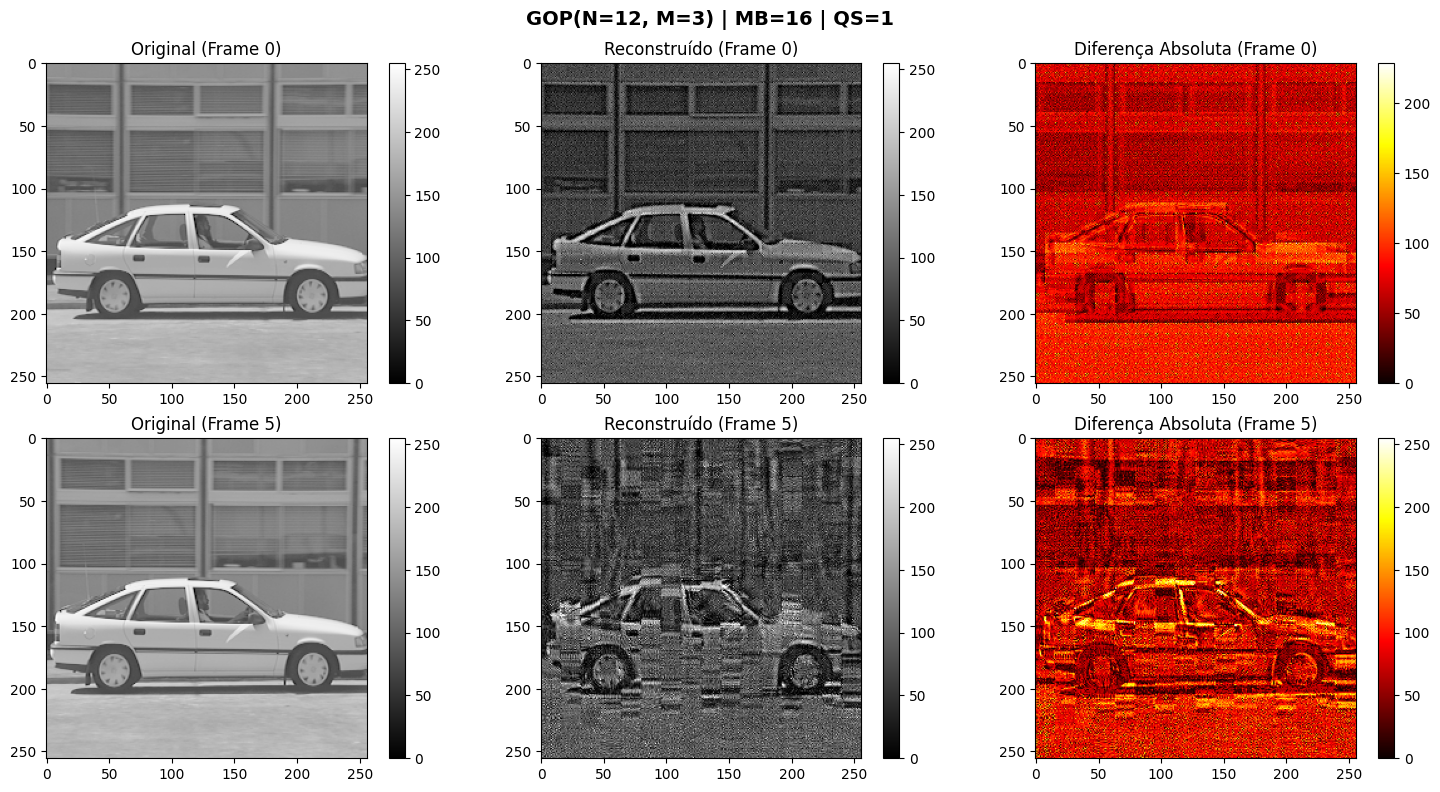

In [36]:
def visualize_reconstruction(compressed_path, frames_y_original, frame_indices=[0, 5, 10]):
    """
    Visualiza comparação entre frames originais e reconstruídos.
    """
    rec_frames, params, metrics = decode_sequence(compressed_path, frames_y_original)
    
    valid_indices = [
        i for i in frame_indices
        if i < len(frames_y_original) and i < len(rec_frames) and rec_frames[i] is not None
    ]
    if not valid_indices:
        print("[INFO] Nenhum frame válido para visualização.")
        return
    
    n_frames_to_show = len(valid_indices)
    fig, axes = plt.subplots(n_frames_to_show, 3, figsize=(15, 4*n_frames_to_show))
    
    if n_frames_to_show == 1:
        axes = axes.reshape(1, -1)
    
    for row, frame_idx in enumerate(valid_indices):
        orig = frames_y_original[frame_idx]
        recon = rec_frames[frame_idx]
        diff = np.abs(orig.astype(np.int16) - recon.astype(np.int16)).astype(np.uint8)
        
        # Original
        im0 = axes[row, 0].imshow(orig, cmap='gray', vmin=0, vmax=255)
        axes[row, 0].set_title(f'Original (Frame {frame_idx})')
        plt.colorbar(im0, ax=axes[row, 0])
        
        # Reconstruído
        im1 = axes[row, 1].imshow(recon, cmap='gray', vmin=0, vmax=255)
        axes[row, 1].set_title(f'Reconstruído (Frame {frame_idx})')
        plt.colorbar(im1, ax=axes[row, 1])
        
        # Diferença
        im2 = axes[row, 2].imshow(diff, cmap='hot')
        axes[row, 2].set_title(f'Diferença Absoluta (Frame {frame_idx})')
        plt.colorbar(im2, ax=axes[row, 2])
        
        # Adiciona métricas
        psnr_val = psnr(orig, recon)
        ssim_val = compute_ssim(orig, recon)
        fig.suptitle(f'GOP(N={params["N"]}, M={params["M"]}) | MB={params["block_size"]} | QS={params["quant_scale"]}', 
                     fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


# Exemplo: visualizar primeiro ficheiro comprimido
if experiment_results and frames_y_original:
    first_result = experiment_results[0]
    compressed_path = os.path.join('compressed', first_result['filename'])
    print(f"\nVisualizando: {first_result['filename']}")
    visualize_reconstruction(compressed_path, frames_y_original, frame_indices=[0, 5, 10])
else:
    print("[INFO] Dados não disponíveis para visualização.")

---
## 2.7 — Resumo e Conclusões

In [18]:
print("""
╔════════════════════════════════════════════════════════════════════════════╗
║           PARTE 2: HYBRID VIDEO DECODING — RESUMO                         ║
╚════════════════════════════════════════════════════════════════════════════╝

FUNÇÕES IMPLEMENTADAS:

2.1.i  — Inverse Quantisation
         • dequantize_block(): inverte quantização de bloco 8x8
         • dequantize_frame(): aplica a todos os blocos de um frame
         • Usa matrizes MPEG (Q_INTRA, Q_INTER) e quality factor (scale)

2.1.ii — Inverse DCT2 Transform
         • apply_idct(): converte coeficientes DCT de volta para pixels
         • apply_idct_to_frame(): aplica a cada bloco 8x8 do frame
         • Usa scipy.fftpack.idct com normalização ortogonal

2.1.iii — Motion-Compensated Reconstruction
         • reconstruct_frame_from_compressed(): recupera frame completo
         • Suporta I-frames (intra), P-frames (predictive), B-frames (bidirectional)
         • Processo: dequantiza → inverse DCT → motion compensation → clip

2.1.iv — Quality Evaluation
         • psnr(): Peak Signal-to-Noise Ratio (dB)
         • compute_ssim(): Structural Similarity Index (range [-1, 1])

EXPERIMENTOS:

Parâmetros variados:
  • Quantiser Scale Factor (QS): 1, 2, 4, 8
  • Macroblock Size (MB): 8×8, 16×16
  • GOP Structure: N=9 (length), M=1, 3 (P-frame distance)

Métricas avaliadas:
  • PSNR: qualidade perceptual (dB) — valores maiores = melhor
  • SSIM: similaridade estrutural — valores próximos de 1 = melhor

RESULTADOS OBSERVADOS:
  1. Quantiser scale: QS maior → mais compressão → menor qualidade
  2. MB size: MBs menores → melhor adaptação → melhor qualidade
  3. GOP structure: M menor → mais P-frames → melhor qualidade, menos compressão

╚════════════════════════════════════════════════════════════════════════════╝
""")


╔════════════════════════════════════════════════════════════════════════════╗
║           PARTE 2: HYBRID VIDEO DECODING — RESUMO                         ║
╚════════════════════════════════════════════════════════════════════════════╝

FUNÇÕES IMPLEMENTADAS:

2.1.i  — Inverse Quantisation
         • dequantize_block(): inverte quantização de bloco 8x8
         • dequantize_frame(): aplica a todos os blocos de um frame
         • Usa matrizes MPEG (Q_INTRA, Q_INTER) e quality factor (scale)

2.1.ii — Inverse DCT2 Transform
         • apply_idct(): converte coeficientes DCT de volta para pixels
         • apply_idct_to_frame(): aplica a cada bloco 8x8 do frame
         • Usa scipy.fftpack.idct com normalização ortogonal

2.1.iii — Motion-Compensated Reconstruction
         • reconstruct_frame_from_compressed(): recupera frame completo
         • Suporta I-frames (intra), P-frames (predictive), B-frames (bidirectional)
         • Processo: dequantiza → inverse DCT → motion compensation 